<a href="https://colab.research.google.com/github/2501407/Statistical-Interpretation-and-Exploratory-Data-Analysis-/blob/starPortfolio/2501407_BharatGautam_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pump it Up: Data Mining the Water **Table**
This dataset is extracted from a data science contest held on [DrivenData.org ](https://www.drivendata.org/competitions/7/pump-it-up-data-mining-the-water-table/page/23/) accessed through [vdwow · Updated 5 years ago](https://www.kaggle.com/datasets/valentindefour/pump-it-up-data-mining-the-water-table/data). The justification of alignment with UNSDG for this data is that it directly supports SDG 6 (Clean Water and Sanitation) by addressing access to reliable water sources.

The dataset contains informations about water pumps located in Tanzania : geography, operating state, installation method, fundings, …

Meaningful questions the dataset can answer:
How can machine learning models classify the operational status of water pumps in rural areas
using geographic, installation, and management data to prioritize maintenance and improve
water access?

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
df_values = pd.read_csv('/content/drive/MyDrive/Level5/AI/CourseWork/Pump_it_Up_Data_Mining_the_Water_Table_-_Training_set_values.csv')


Mounted at /content/drive


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
# Sklearn for Preprocessing and Metrics
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# Sklearn for Models
from sklearn.neural_network import MLPClassifier # For Task 2
from sklearn.ensemble import RandomForestClassifier # Classical Model 1
from sklearn.neighbors import KNeighborsClassifier  # Classical Model 2

# Feature Selection
from sklearn.feature_selection import SelectFromModel

# Configuration
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [4]:
df_label = pd.read_csv('/content/drive/MyDrive/Level5/AI/CourseWork/Pump_it_Up_Data_Mining_the_Water_Table_-_Training_set_labels.csv')

# Merge values and labels on 'id' to create a complete dataframe
df = pd.merge(df_values, df_label, on='id')

# DATASET DESCRIPTION & UNSDG ALIGNMENT
print("Dataset Shape:", df.shape)
print("\nUNSDG Alignment")
print("This dataset aligns with UNSDG Goal 6: Clean Water and Sanitation.")
print("The objective is to predict which water pumps are functional, needing repair, or non-functional.")

print("\nMeaningful Questions")
print("1. Which geographic regions have the highest failure rates?")
print("2. Does the age of the pump (construction year) correlate with failure?")
print("3. Which installer has the best track record for functional pumps?")

# Preview Data
df.head()

Dataset Shape: (59400, 41)

UNSDG Alignment
This dataset aligns with UNSDG Goal 6: Clean Water and Sanitation.
The objective is to predict which water pumps are functional, needing repair, or non-functional.

Meaningful Questions
1. Which geographic regions have the highest failure rates?
2. Does the age of the pump (construction year) correlate with failure?
3. Which installer has the best track record for functional pumps?


,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,basin,subvillage,region,region_code,district_code,lga,ward,population,public_meeting,recorded_by,scheme_management,scheme_name,permit,construction_year,extraction_type,extraction_type_group,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,Lake Nyasa,Mnyusi B,Iringa,11,5,Ludewa,Mundindi,109,True,GeoData Consultants Ltd,VWC,Roman,False,1999,gravity,gravity,gravity,vwc,user-group,pay annually,annually,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,Lake Victoria,Nyamara,Mara,20,2,Serengeti,Natta,280,NaN,GeoData Consultants Ltd,Other,NaN,True,2010,gravity,gravity,gravity,wug,user-group,never pay,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,Pangani,Majengo,Manyara,21,4,Simanjiro,Ngorika,250,True,GeoData Consultants Ltd,VWC,Nyumba ya mungu pipe scheme,True,2009,gravity,gravity,gravity,vwc,user-group,pay per bucket,per bucket,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,Ruvuma / Southern Coast,Mahakamani,Mtwara,90,63,Nanyumbu,Nanyumbu,58,True,GeoData Consultants Ltd,VWC,NaN,True,1986,submersible,submersible,submersible,vwc,user-group,never pay,never pay,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,Lake Victoria,Kyanyamisa,Kagera,18,1,Karagwe,Nyakasimbi,0,True,GeoData Consultants Ltd,NaN,NaN,True,0,gravity,gravity,gravity,other,other,never pay,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional


In [5]:
# Drop columns that are irrelevant (IDs) or too granular for this baseline
cols_to_drop = ['id', 'date_recorded', 'wpt_name', 'num_private', 'subvillage',
                'region_code', 'district_code', 'lga', 'ward', 'recorded_by', 'scheme_name']
df_clean = df.drop(columns=cols_to_drop)

# Handling Missing Values
# Fill categorical NaNs with 'Unknown' and numerical with median
cat_cols = df_clean.select_dtypes(include=['object']).columns
num_cols = df_clean.select_dtypes(include=['number']).columns

# Simple imputation strategy
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna('Unknown')

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())


In [7]:
print("DUPLICATE DETECTION AND REMOVAL")
duplicates_before = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates_before}")
if duplicates_before > 0:
    df_clean = df.drop_duplicates()
    print(f"Removed {duplicates_before} duplicate rows")
else:
    print("No duplicates found!")

DUPLICATE DETECTION AND REMOVAL
Number of duplicate rows: 0
No duplicates found!


In [11]:
print("Dataset Shape after cleaning:", df_clean.shape)
print("\nData types:")
print(df_clean.dtypes)

print("\nBasic statistics for numeric columns:")
print(df_clean.describe())

print("\nCategorical column value counts:")
for col in df_clean.select_dtypes(include=['object']).columns:
    print(f"\n{col}: {df_clean[col].nunique()} unique values")

Dataset Shape after cleaning: (59400, 30)

Data types:
amount_tsh               float64
funder                    object
gps_height                 int64
installer                 object
longitude                float64
latitude                 float64
basin                     object
region                    object
population                 int64
public_meeting            object
scheme_management         object
permit                    object
construction_year          int64
extraction_type           object
extraction_type_group     object
extraction_type_class     object
management                object
management_group          object
payment                   object
payment_type              object
water_quality             object
quality_group             object
quantity                  object
quantity_group            object
source                    object
source_type               object
source_class              object
waterpoint_type           object
waterpoint_type_group

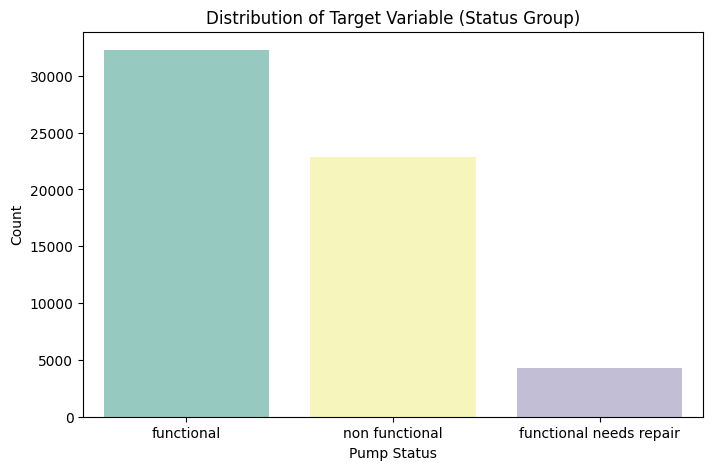

Insight: The dataset is imbalanced. 'Functional' is the majority class, while 'Functional needs repair' is the minority.


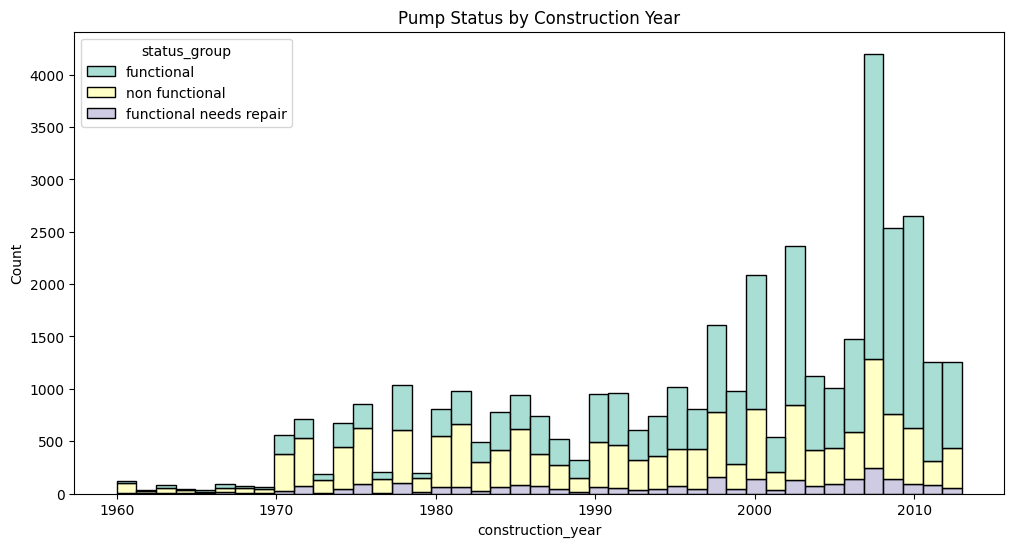

Insight: Older pumps have a higher proportion of non-functional status.


In [12]:
# EDA VISUALIZATIONS
plt.figure(figsize=(8, 5))
sns.countplot(x='status_group', data=df_clean, palette='Set3')
plt.title('Distribution of Target Variable (Status Group)')
plt.xlabel('Pump Status')
plt.ylabel('Count')
plt.show()

print("Insight: The dataset is imbalanced. 'Functional' is the majority class, while 'Functional needs repair' is the minority.")

plt.figure(figsize=(12, 6))
# Filter out 0s in construction_year as they are likely missing values
df_year = df_clean[df_clean['construction_year'] > 0]
sns.histplot(data=df_year, x='construction_year', hue='status_group', multiple="stack", palette='Set3')
plt.title('Pump Status by Construction Year')
plt.show()

print("Insight: Older pumps have a higher proportion of non-functional status.")

In [13]:
# Split Features and Target
X = df_clean.drop('status_group', axis=1)
y = df_clean['status_group']

# Encode Target Variable
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y) # 0: functional, 1: needs repair, 2: non functional

# Encode Categorical Features (Label Encoding for simplicity/memory efficiency)
X_encoded = X.copy()
for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    # Convert to string to handle mixed types if any
    X_encoded[col] = le.fit_transform(X[col].astype(str))

# Split into Train and Test Sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Scale Data (Crucial for Neural Networks and KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Preprocessing Complete.")
print(f"Training Shape: {X_train_scaled.shape}, Test Shape: {X_test_scaled.shape}")

Data Preprocessing Complete.
Training Shape: (47520, 29), Test Shape: (11880, 29)


In [14]:
# Architecture: MLP (Multi-Layer Perceptron)
# Input Layer -> Hidden Layer 1 (100 neurons) -> Hidden Layer 2 (50 neurons) -> Output Layer (3 classes)
# Activation: ReLU, Optimizer: Adam

mlp_model = MLPClassifier(hidden_layer_sizes=(100, 50),
                          activation='relu',
                          solver='adam',
                          max_iter=200,
                          random_state=42)

print("Training Neural Network...")
mlp_model.fit(X_train_scaled, y_train)

# Evaluation
y_pred_mlp = mlp_model.predict(X_test_scaled)
acc_mlp = accuracy_score(y_test, y_pred_mlp)
f1_mlp = f1_score(y_test, y_pred_mlp, average='weighted')

print("\nNeural Network Results")
print(f"Accuracy: {acc_mlp:.4f}")
print(f"F1 Score (Weighted): {f1_mlp:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_mlp, target_names=le_target.classes_))

Training Neural Network...

Neural Network Results
Accuracy: 0.7672
F1 Score (Weighted): 0.7567

Classification Report:
                          precision    recall  f1-score   support

             functional       0.78      0.85      0.82      6452
functional needs repair       0.48      0.22      0.30       863
         non functional       0.77      0.75      0.76      4565

               accuracy                           0.77     11880
              macro avg       0.68      0.61      0.63     11880
           weighted avg       0.76      0.77      0.76     11880



In [15]:
# Model 1: Random Forest (Ensemble Method)
# Good for handling complex interactions and doesn't strictly require scaling (but we use scaled for consistency)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Model 2: K-Nearest Neighbors (KNN)
# Distance-based algorithm
knn_model = KNeighborsClassifier(n_neighbors=5)

# Training
print("Training Random Forest...")
rf_model.fit(X_train_scaled, y_train)

print("Training KNN...")
knn_model.fit(X_train_scaled, y_train)

# Evaluation
# Random Forest
y_pred_rf = rf_model.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

# KNN
y_pred_knn = knn_model.predict(X_test_scaled)
acc_knn = accuracy_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn, average='weighted')

print("\nClassical Models Initial Results")
print(f"Random Forest - Accuracy: {acc_rf:.4f}, F1: {f1_rf:.4f}")
print(f"KNN           - Accuracy: {acc_knn:.4f}, F1: {f1_knn:.4f}")

print("\nConclusion: Random Forest generally performs better on tabular data with categorical features.")

Training Random Forest...
Training KNN...

Classical Models Initial Results
Random Forest - Accuracy: 0.8061, F1: 0.7994
KNN           - Accuracy: 0.7714, F1: 0.7638

Conclusion: Random Forest generally performs better on tabular data with categorical features.


In [16]:
# Using RandomizedSearchCV to save computation time compared to GridSearch

# 1. Random Forest Tuning
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# 2. KNN Tuning
knn_params = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance']
}

print("Tuning Random Forest...")
rf_search = RandomizedSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=3, n_iter=5, scoring='accuracy', random_state=42, n_jobs=-1)
rf_search.fit(X_train_scaled, y_train)

print("Tuning KNN...")
knn_search = RandomizedSearchCV(KNeighborsClassifier(), knn_params, cv=3, n_iter=5, scoring='accuracy', random_state=42, n_jobs=-1)
knn_search.fit(X_train_scaled, y_train)

print("\nOptimization Results")
print(f"Best RF Params: {rf_search.best_params_}")
print(f"Best RF CV Score: {rf_search.best_score_:.4f}")
print(f"Best KNN Params: {knn_search.best_params_}")
print(f"Best KNN CV Score: {knn_search.best_score_:.4f}")

Tuning Random Forest...
Tuning KNN...

Optimization Results
Best RF Params: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 20}
Best RF CV Score: 0.8045
Best KNN Params: {'weights': 'distance', 'n_neighbors': 7}
Best KNN CV Score: 0.7642


In [17]:
# Technique: Embedded Method (SelectFromModel using Random Forest)
# Rationale: This selects features that contribute most to the information gain.

print("Performing Feature Selection...")

# We use the best RF model found to determine feature importance
selector = SelectFromModel(rf_search.best_estimator_, threshold='median', prefit=True)

# Transform datasets to keep only selected features
X_train_selected = selector.transform(X_train_scaled)
X_test_selected = selector.transform(X_test_scaled)

selected_feat_count = X_train_selected.shape[1]
original_feat_count = X_train_scaled.shape[1]

print(f"Original Feature Count: {original_feat_count}")
print(f"Selected Feature Count: {selected_feat_count}")
print("Feature Selection applied to both models' input data.")

Performing Feature Selection...
Original Feature Count: 29
Selected Feature Count: 15
Feature Selection applied to both models' input data.


In [18]:
# Rebuild Models with Best Hyperparameters AND Selected Features

# 1. Final Random Forest
final_rf = rf_search.best_estimator_
final_rf.fit(X_train_selected, y_train)
final_rf_pred = final_rf.predict(X_test_selected)

# 2. Final KNN (using parameters from before, but trained on selected features)
final_knn = knn_search.best_estimator_
final_knn.fit(X_train_selected, y_train)
final_knn_pred = final_knn.predict(X_test_selected)

# Calculate Metrics
metrics_rf = {
    'Accuracy': accuracy_score(y_test, final_rf_pred),
    'Precision': classification_report(y_test, final_rf_pred, output_dict=True)['weighted avg']['precision'],
    'Recall': classification_report(y_test, final_rf_pred, output_dict=True)['weighted avg']['recall'],
    'F1-Score': f1_score(y_test, final_rf_pred, average='weighted')
}

metrics_knn = {
    'Accuracy': accuracy_score(y_test, final_knn_pred),
    'Precision': classification_report(y_test, final_knn_pred, output_dict=True)['weighted avg']['precision'],
    'Recall': classification_report(y_test, final_knn_pred, output_dict=True)['weighted avg']['recall'],
    'F1-Score': f1_score(y_test, final_knn_pred, average='weighted')
}

# Create Comparison Table (DataFrame)
comparison_df = pd.DataFrame([metrics_rf, metrics_knn], index=['Random Forest (Optimized)', 'KNN (Optimized)'])

print("\nTable 1: Comparison of Final Classification Models")
display(comparison_df)

# Final Conclusion for the Report
best_model = comparison_df['F1-Score'].idxmax()
print(f"\nConclusion: Based on F1-Score, the {best_model} is the superior model for this task.")


Table 1: Comparison of Final Classification Models


,Accuracy,Precision,Recall,F1-Score
Random Forest (Optimized),0.805976,0.799251,0.805976,0.795491
KNN (Optimized),0.774495,0.765527,0.774495,0.767854



Conclusion: Based on F1-Score, the Random Forest (Optimized) is the superior model for this task.
